In [1]:
import gpxpy
import gpxpy.gpx

gpx_file = open("BWSC route_gpx/Route1.gpx", "r")

gpx = gpxpy.parse(gpx_file)

# track -> segment -> point

for track in gpx.tracks:
    for segment in track.segments:
        # 현재 데이터는 segmentation단위로 쪼개지 않아서 각 Route데이터는 segmentation이 하나임
        
        for point in segment.points:
            print(f"latitude : {point.latitude}, longitude : {point.longitude}, elevation : {point.elevation}")
    

latitude : -12.4660184, longitude : 130.8427841, elevation : 38.688
latitude : -12.4660184, longitude : 130.8427841, elevation : 38.688
latitude : -12.4658107, longitude : 130.8425507, elevation : 36.326
latitude : -12.4657705, longitude : 130.8425191, elevation : 36.905
latitude : -12.4657315, longitude : 130.842498, elevation : 37.471
latitude : -12.4656939, longitude : 130.8424906, elevation : 38.025
latitude : -12.4655495, longitude : 130.8424883, elevation : 40.021
latitude : -12.4655507, longitude : 130.8425367, elevation : 40.017
latitude : -12.4655458, longitude : 130.8425684, elevation : 40.035
latitude : -12.4655367, longitude : 130.842598, elevation : 40.068
latitude : -12.4655233, longitude : 130.8426266, elevation : 40.116
latitude : -12.4654958, longitude : 130.8426722, elevation : 40.215
latitude : -12.4654641, longitude : 130.8427108, elevation : 40.329
latitude : -12.4654285, longitude : 130.8427624, elevation : 40.457
latitude : -12.4653909, longitude : 130.8427913, e

In [2]:
import pandas as pd

route1 = pd.read_csv("BWSC route_csv/Route1.csv")
route1

,ele,lat,lon,name
0,38.688,-12.466018,130.842784,Route
1,38.688,-12.466018,130.842784,Route
2,36.326,-12.465811,130.842551,Route
3,36.905,-12.465770,130.842519,Route
4,37.471,-12.465732,130.842498,Route
...,...,...,...,...
5452,113.059,-14.481378,132.324323,Route
5453,113.113,-14.481399,132.324477,Route
5454,113.626,-14.481453,132.324670,Route
5455,113.440,-14.481545,132.325030,Route


In [3]:
route1.drop('name', axis=1, inplace=True)

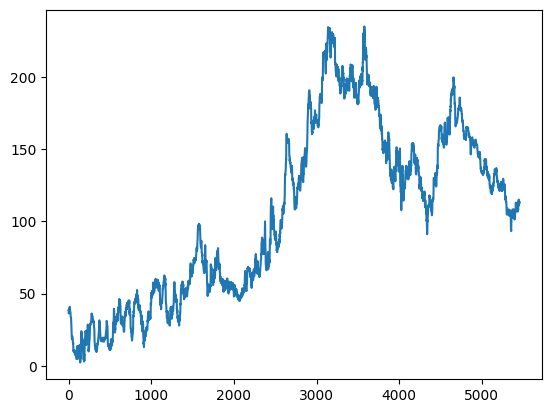

In [4]:
import matplotlib.pyplot as plt

plt.plot(route1.index, route1['ele'])

In [5]:
import os

l = []

for file in os.listdir("BWSC route_csv"):
    l.append(file)
    print(file)
    
l.append(l[1])
l.pop(1)
print(l)

Route1.csv
Route10.csv
Route2.csv
Route3.csv
Route4.csv
Route5.csv
Route6.csv
Route7.csv
Route8.csv
Route9.csv
['Route1.csv', 'Route2.csv', 'Route3.csv', 'Route4.csv', 'Route5.csv', 'Route6.csv', 'Route7.csv', 'Route8.csv', 'Route9.csv', 'Route10.csv']


In [6]:
Route_all = pd.DataFrame()

for file in l:
    df = pd.read_csv(f"BWSC route_csv/{file}")
    Route_all = pd.concat([Route_all, df], axis=0)
    
Route_all

,ele,lat,lon,name
0,38.688,-12.466018,130.842784,Route
1,38.688,-12.466018,130.842784,Route
2,36.326,-12.465811,130.842551,Route
3,36.905,-12.465770,130.842519,Route
4,37.471,-12.465732,130.842498,Route
...,...,...,...,...
4678,58.158,-34.927596,138.621069,Route10
4679,57.578,-34.927588,138.620891,Route10
4680,57.991,-34.927589,138.620574,Route10
4681,55.831,-34.927662,138.619010,Route10


<h3>해상도는 약 80m정도 (0.0079km/point)</h3>

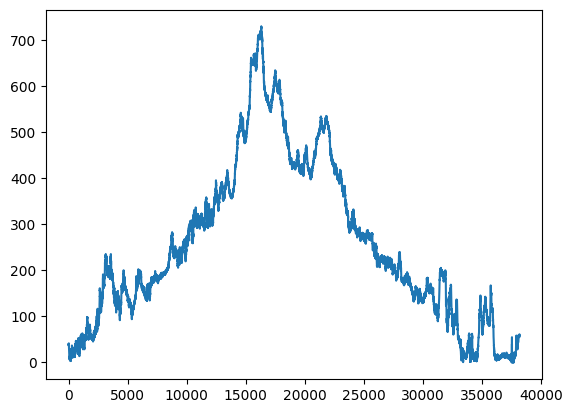

In [7]:
Route_all = Route_all.reset_index(drop=True)
plt.plot(Route_all.index, Route_all['ele'])

In [8]:
import gymnasium as gym
from gymnasium.wrappers import FlattenObservation

env = gym.make("CarRacing-v3", render_mode='human')
env.observation_space.shape

c:\Users\dlwns\miniconda3\envs\kust\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


(96, 96, 3)

In [9]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic

df = Route_all.copy()

distances = [0]

for i in range(1, len(df)):
    p1 = (df.loc[i-1, 'lat'], df.loc[i-1, 'lon'])
    p2 = (df.loc[i, 'lat'], df.loc[i, 'lon'])
    
    d = geodesic(p1, p2).meters
    distances.append(distances[-1] + d)
    
df["distnace"] = distances

In [10]:
df

,ele,lat,lon,name,distnace
0,38.688,-12.466018,130.842784,Route,0.000000e+00
1,38.688,-12.466018,130.842784,Route,0.000000e+00
2,36.326,-12.465811,130.842551,Route,3.423087e+01
3,36.905,-12.465770,130.842519,Route,3.985036e+01
4,37.471,-12.465732,130.842498,Route,4.473665e+01
...,...,...,...,...,...
38205,58.158,-34.927596,138.621069,Route10,3.030819e+06
38206,57.578,-34.927588,138.620891,Route10,3.030835e+06
38207,57.991,-34.927589,138.620574,Route10,3.030864e+06
38208,55.831,-34.927662,138.619010,Route10,3.031008e+06


In [11]:
df["grade"] = np.gradient(df["ele"], df["distnace"])

c:\Users\dlwns\miniconda3\envs\kust\Lib\site-packages\numpy\lib\_function_base_impl.py:1317: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
c:\Users\dlwns\miniconda3\envs\kust\Lib\site-packages\numpy\lib\_function_base_impl.py:1317: RuntimeWarning: invalid value encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
c:\Users\dlwns\miniconda3\envs\kust\Lib\site-packages\numpy\lib\_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\dlwns\miniconda3\envs\kust\Lib\site-packages\numpy\lib\_function_base_impl.py:1318: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\dlwns\miniconda3\envs\kust\Lib\site-packages\numpy\lib\_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\dlwns\miniconda3\envs\kust\Lib\site-packages\numpy\lib\_function_base_impl.py:1319: RuntimeWarnin

In [12]:
df = df.fillna(0)
df

,ele,lat,lon,name,distnace,grade
0,38.688,-12.466018,130.842784,Route,0.000000e+00,0.000000
1,38.688,-12.466018,130.842784,Route,0.000000e+00,0.000000
2,36.326,-12.465811,130.842551,Route,3.423087e+01,0.078775
3,36.905,-12.465770,130.842519,Route,3.985036e+01,0.109881
4,37.471,-12.465732,130.842498,Route,4.473665e+01,0.123831
...,...,...,...,...,...,...
38205,58.158,-34.927596,138.621069,Route10,3.030819e+06,-0.030067
38206,57.578,-34.927588,138.620891,Route10,3.030835e+06,-0.017712
38207,57.991,-34.927589,138.620574,Route10,3.030864e+06,0.009285
38208,55.831,-34.927662,138.619010,Route10,3.031008e+06,0.003984


In [13]:
route_data = pd.read_csv("2025-08-01~30/1_PT5M.csv")
print(route_data.info())
route_data

<class 'pandas.DataFrame'>
RangeIndex: 8640 entries, 0 to 8639
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   air_temp            8640 non-null   int64  
 1   azimuth             8640 non-null   int64  
 2   cloud_opacity       8640 non-null   float64
 3   ghi                 8640 non-null   int64  
 4   gti                 8640 non-null   int64  
 5   precipitation_rate  8640 non-null   float64
 6   surface_pressure    8640 non-null   float64
 7   wind_direction_10m  8640 non-null   int64  
 8   wind_speed_10m      8640 non-null   float64
 9   zenith              8640 non-null   int64  
 10  weather_type        8640 non-null   str    
 11  pm10                8640 non-null   float64
 12  pm2.5               8640 non-null   float64
 13  period_end          8640 non-null   str    
 14  period              8640 non-null   str    
dtypes: float64(6), int64(6), str(3)
memory usage: 1012.6 KB
None


,air_temp,azimuth,cloud_opacity,ghi,gti,precipitation_rate,surface_pressure,wind_direction_10m,wind_speed_10m,zenith,weather_type,pm10,pm2.5,period_end,period
0,25,62,33.6,0,0,0.1,1015.0,249,1.0,166,PARTLY CLOUDY,44.3,19.9,2025-08-01T00:05:00+09:30,PT5M
1,25,60,32.0,0,0,0.1,1015.1,251,1.0,167,PARTLY CLOUDY,44.6,20.0,2025-08-01T00:10:00+09:30,PT5M
2,25,57,26.8,0,0,0.1,1015.1,252,0.9,168,PARTLY CLOUDY,44.8,20.2,2025-08-01T00:15:00+09:30,PT5M
3,25,53,26.8,0,0,0.1,1015.1,254,0.9,169,PARTLY CLOUDY,45.0,20.3,2025-08-01T00:20:00+09:30,PT5M
4,25,49,26.8,0,0,0.1,1015.1,255,0.9,170,PARTLY CLOUDY,45.2,20.4,2025-08-01T00:25:00+09:30,PT5M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8635,25,98,21.4,0,0,0.0,1015.4,50,1.5,163,PARTLY CLOUDY,70.2,19.3,2025-08-30T23:40:00+09:30,PT5M
8636,25,99,19.6,0,0,0.0,1015.3,53,1.4,164,PARTLY CLOUDY,70.0,19.3,2025-08-30T23:45:00+09:30,PT5M
8637,25,100,19.6,0,0,0.0,1015.3,57,1.4,165,PARTLY CLOUDY,69.8,19.2,2025-08-30T23:50:00+09:30,PT5M
8638,24,101,19.6,0,0,0.0,1015.3,61,1.3,166,PARTLY CLOUDY,69.6,19.1,2025-08-30T23:55:00+09:30,PT5M


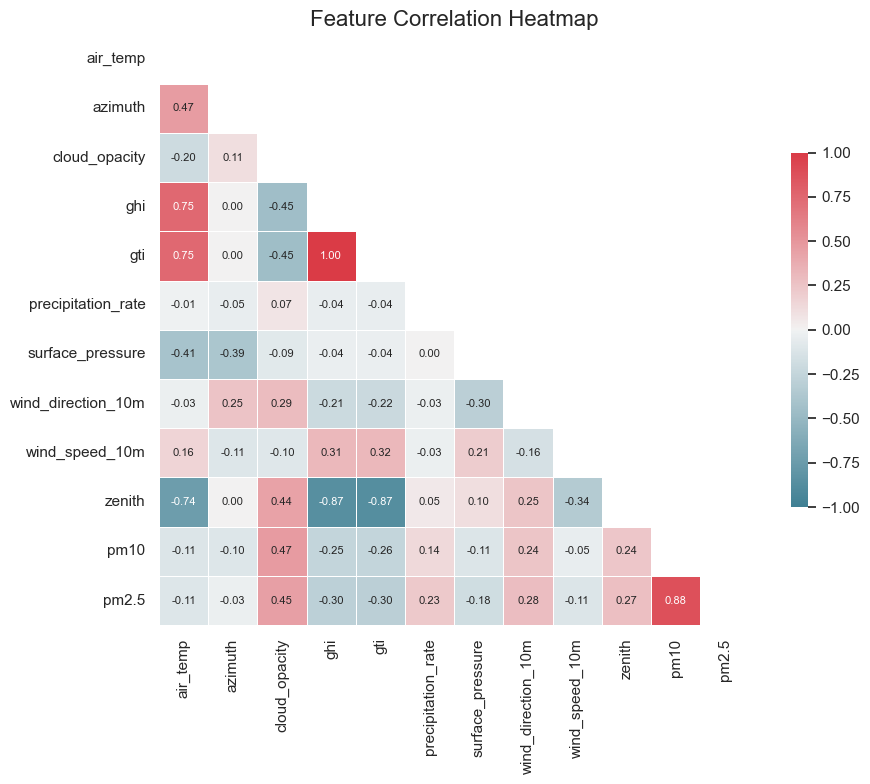

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot a prettier correlation heatmap
plt.figure(figsize=(10, 8))
sns.set(style="white")

n_df = route_data.select_dtypes(exclude='str')
corr = n_df.corr()

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.6},
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()